# Inspecting the Moana Ocean Hindcast: surface fields

**Purpose:** First look at the published Moana Ocean Hindcast output. These plots show what the reference solution looks like, so can be compared to later.

**Data:** Moana Ocean Hindcast v2 (ROMS, 5 km, 50 s-levels), daily-averaged output from the Moana Project THREDDS server.
Reference: Azevedo Correia de Souza et al. (2023), *Geosci. Model Dev.*, 16, 211–231, https://doi.org/10.5194/gmd-16-211-2023

**File:** `http://131.203.52.77:6443/thredds/catalog/moana/NZB/moana_backbone_v2.2/avg/catalog.html`

## Variables plotted

| Variable | Description | Units | Grid points |
|---|---|---|---|
| `temp` | Potential temperature | °C | rho (cell centres) |
| `salt` | Salinity | — | rho (cell centres) |
| `zeta` | Sea surface height | m | rho (cell centres) |
| `u` | Velocity along the grid's ξ direction (≈ east) | m/s | u (cell east/west faces) |
| `v` | Velocity along the grid's η direction (≈ north) | m/s | v (cell north/south faces) |

## Notes
- 3D variables are plotted at the surface level (`s_rho = -1`)

In [1]:
# Import needed packages 
import xarray as xr
import matplotlib.pyplot as plt 
import numpy as np 
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Assign data url from THREDDS
fileurl = "http://131.203.52.77:6443/thredds/dodsC/moana/NZB/moana_backbone_v2.2/avg/nz5km_avg_201901.nc"

# Open with xarray to observe dataset
ds = xr.open_dataset(fileurl)
print(ds)

<xarray.Dataset> Size: 7GB
Dimensions:        (tracer: 2, boundary: 4, s_rho: 50, s_w: 51, Nuser: 25,
                    eta_rho: 467, xi_rho: 397, eta_u: 467, xi_u: 396,
                    eta_v: 466, xi_v: 397, eta_psi: 466, xi_psi: 396,
                    ocean_time: 31)
Coordinates:
  * s_rho          (s_rho) float64 400B -0.9849 -0.9552 ... -0.01515 -0.004949
  * s_w            (s_w) float64 408B -1.0 -0.97 -0.9404 ... -0.02041 -0.01 0.0
    lon_rho        (eta_rho, xi_rho) float64 1MB ...
    lat_rho        (eta_rho, xi_rho) float64 1MB ...
    lon_u          (eta_u, xi_u) float64 1MB ...
    lat_u          (eta_u, xi_u) float64 1MB ...
    lon_v          (eta_v, xi_v) float64 1MB ...
    lat_v          (eta_v, xi_v) float64 1MB ...
    lon_psi        (eta_psi, xi_psi) float64 1MB ...
    lat_psi        (eta_psi, xi_psi) float64 1MB ...
  * ocean_time     (ocean_time) datetime64[ns] 248B 2019-01-01T12:00:00 ... 2...
Dimensions without coordinates: tracer, boundary, Nuser, eta_

/tmp/ipykernel_218459/2301165982.py:11: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(fileurl)


In [ ]:
# Check variables in the dataset
print(list(ds.data_vars))

['ntimes', 'ndtfast', 'dt', 'dtfast', 'dstart', 'nHIS', 'ndefHIS', 'nRST', 'ntsAVG', 'nAVG', 'ndefAVG', 'Falpha', 'Fbeta', 'Fgamma', 'nl_tnu2', 'nl_visc2', 'LuvSponge', 'LtracerSponge', 'Akt_bak', 'Akv_bak', 'Akk_bak', 'Akp_bak', 'rdrg', 'rdrg2', 'Zob', 'Zos', 'Znudg', 'M2nudg', 'M3nudg', 'Tnudg', 'FSobc_in', 'FSobc_out', 'M2obc_in', 'M2obc_out', 'Tobc_in', 'Tobc_out', 'M3obc_in', 'M3obc_out', 'rho0', 'gamma2', 'LuvSrc', 'LwSrc', 'LtracerSrc', 'LsshCLM', 'Lm2CLM', 'Lm3CLM', 'LtracerCLM', 'LnudgeM2CLM', 'LnudgeM3CLM', 'LnudgeTCLM', 'spherical', 'xl', 'el', 'Vtransform', 'Vstretching', 'theta_s', 'theta_b', 'Tcline', 'hc', 'grid', 'Cs_r', 'Cs_w', 'user', 'h', 'f', 'pm', 'pn', 'angle', 'mask_rho', 'mask_u', 'mask_v', 'mask_psi', 'zeta', 'ubar', 'vbar', 'u', 'v', 'omega', 'w', 'temp', 'salt']


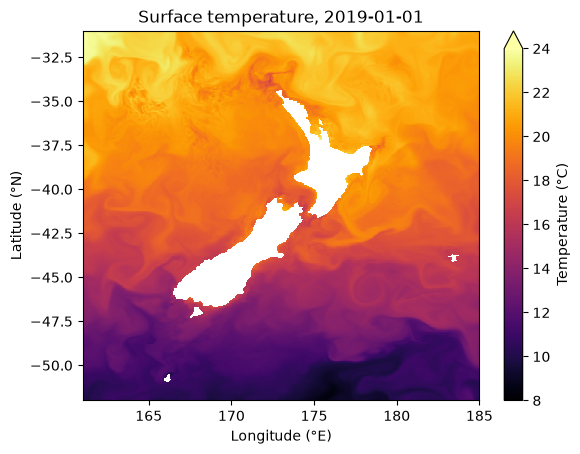

In [ ]:
# --- Plot Temperature ---
temp = ds["temp"].isel(ocean_time=0, s_rho=-1)

temp.plot(x="lon_rho", y="lat_rho", cmap="inferno", vmin=8, vmax=24,
          cbar_kwargs={"label": "Temperature (°C)"})

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"Surface temperature, {str(temp.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_temp.png", dpi=200, bbox_inches="tight")
plt.show()

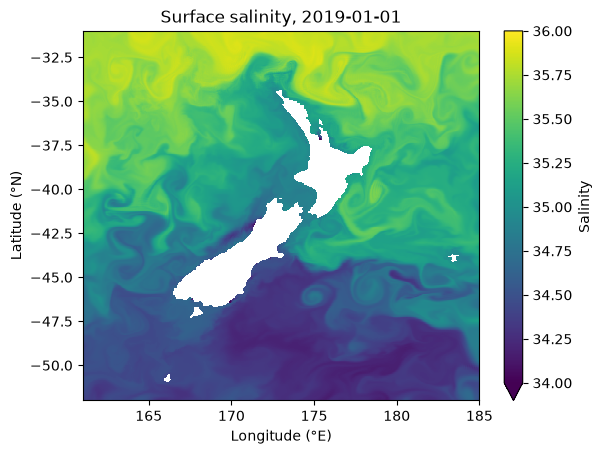

In [ ]:
# --- Plot Salinity ---
salt = ds["salt"].isel(ocean_time=0, s_rho=-1)

salt.plot(x="lon_rho", y="lat_rho", cmap="viridis", vmin=34, vmax=36,
          cbar_kwargs={"label": "Salinity"})

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"Surface salinity, {str(salt.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_salt.png", dpi=200, bbox_inches="tight")
plt.show()

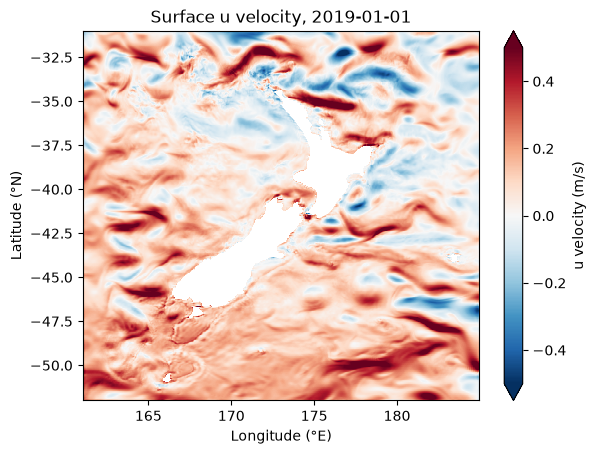

In [ ]:
# --- Plot u Surface Velocity ---
u = ds["u"].isel(ocean_time=0, s_rho=-1)

u.plot(x="lon_u", y="lat_u", cmap="RdBu_r", vmin=-0.5, vmax=0.5,
       cbar_kwargs={"label": "u velocity (m/s)"})

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"Surface u velocity, {str(u.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_u.png", dpi=200, bbox_inches="tight")
plt.show()


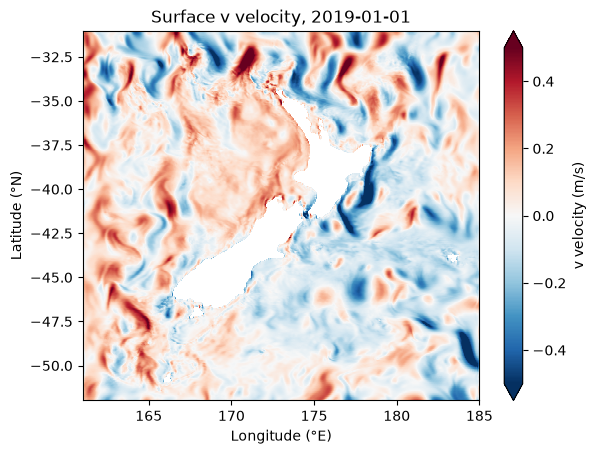

In [ ]:
# --- Plot v Surface Velocity ---
v = ds["v"].isel(ocean_time=0, s_rho=-1)

v.plot(x="lon_v", y="lat_v", cmap="RdBu_r", vmin=-0.5, vmax=0.5,
       cbar_kwargs={"label": "v velocity (m/s)"})

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"Surface v velocity, {str(v.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_v.png", dpi=200, bbox_inches="tight")
plt.show()

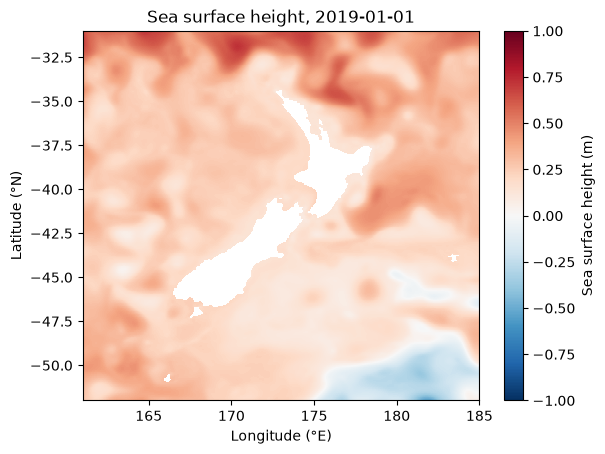

In [ ]:
# --- Plot Sea Surface Height ---
zeta = ds["zeta"].isel(ocean_time=0)

zeta.plot(x="lon_rho", y="lat_rho", cmap="RdBu_r", vmin=-1, vmax=1,
          cbar_kwargs={"label": "Sea surface height (m)"})

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title(f"Sea surface height, {str(zeta.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_ssh.png", dpi=200, bbox_inches="tight")
plt.show()

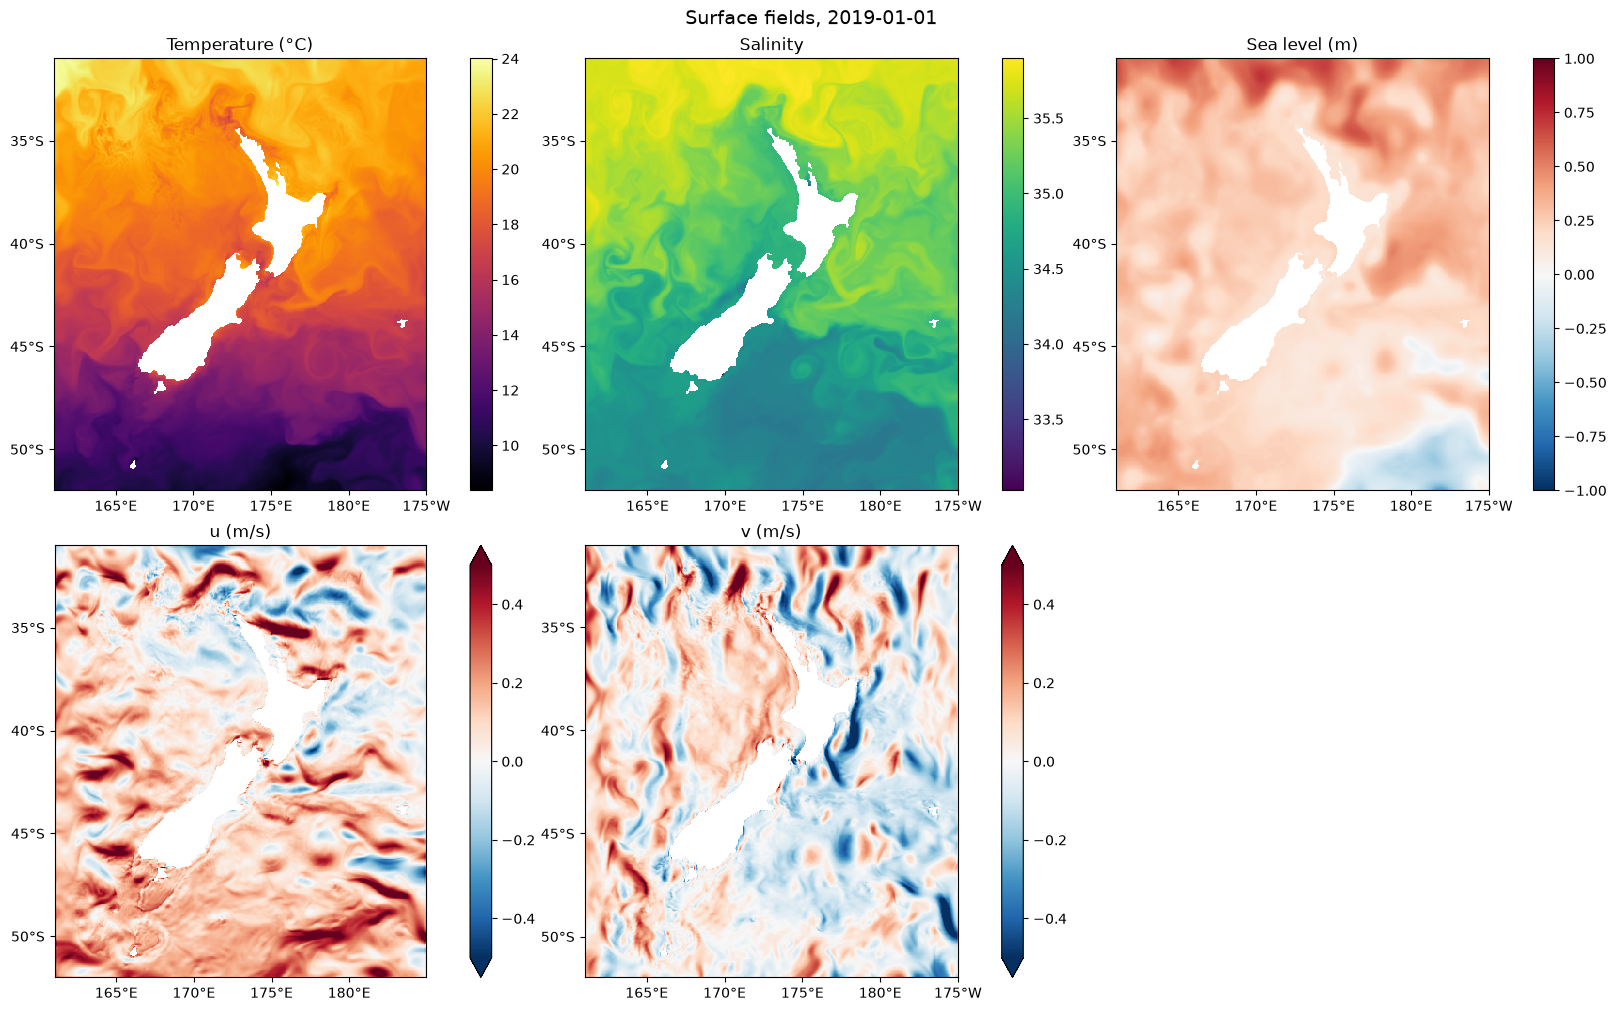

In [ ]:
# --- Plot All 5 Variables ---
t = 0                                  # time step
s = ds.isel(ocean_time=t, s_rho=-1)    # surface level, one time

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
nolabel = {"label": ""}                # hide the long colourbar text

s["temp"].plot(ax=axes[0, 0], x="lon_rho", y="lat_rho", cmap="inferno", cbar_kwargs=nolabel)
s["salt"].plot(ax=axes[0, 1], x="lon_rho", y="lat_rho", cmap="viridis", cbar_kwargs=nolabel)
s["zeta"].plot(ax=axes[0, 2], x="lon_rho", y="lat_rho", cmap="RdBu_r", vmin=-1,   vmax=1,   cbar_kwargs=nolabel)
s["u"].plot(   ax=axes[1, 0], x="lon_u",   y="lat_u",   cmap="RdBu_r", vmin=-0.5, vmax=0.5, cbar_kwargs=nolabel)
s["v"].plot(   ax=axes[1, 1], x="lon_v",   y="lat_v",   cmap="RdBu_r", vmin=-0.5, vmax=0.5, cbar_kwargs=nolabel)

axes[0, 0].set_title("Temperature (°C)")
axes[0, 1].set_title("Salinity")
axes[0, 2].set_title("Sea level (m)")
axes[1, 0].set_title("u (m/s)")
axes[1, 1].set_title("v (m/s)")
axes[1, 2].set_visible(False)          # empty 6th panel

# map-style tick labels: 170°E, 175°W, 40°S
lon_fmt = FuncFormatter(lambda x, _: f"{x:.0f}°E" if x <= 180 else f"{360 - x:.0f}°W")
lat_fmt = FuncFormatter(lambda y, _: f"{abs(y):.0f}°S")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.xaxis.set_major_locator(MultipleLocator(5))   # a tick every 5°
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(lon_fmt)
    ax.yaxis.set_major_formatter(lat_fmt)
    ax.set_aspect(1 / np.cos(np.deg2rad(41)))        # true map proportions at ~41°S

fig.suptitle(f"Surface fields, {str(s.ocean_time.values)[:10]}", fontsize=14)

plt.savefig("../Figures/Jan2019_all_variables.png", dpi=200, bbox_inches="tight")
plt.show()

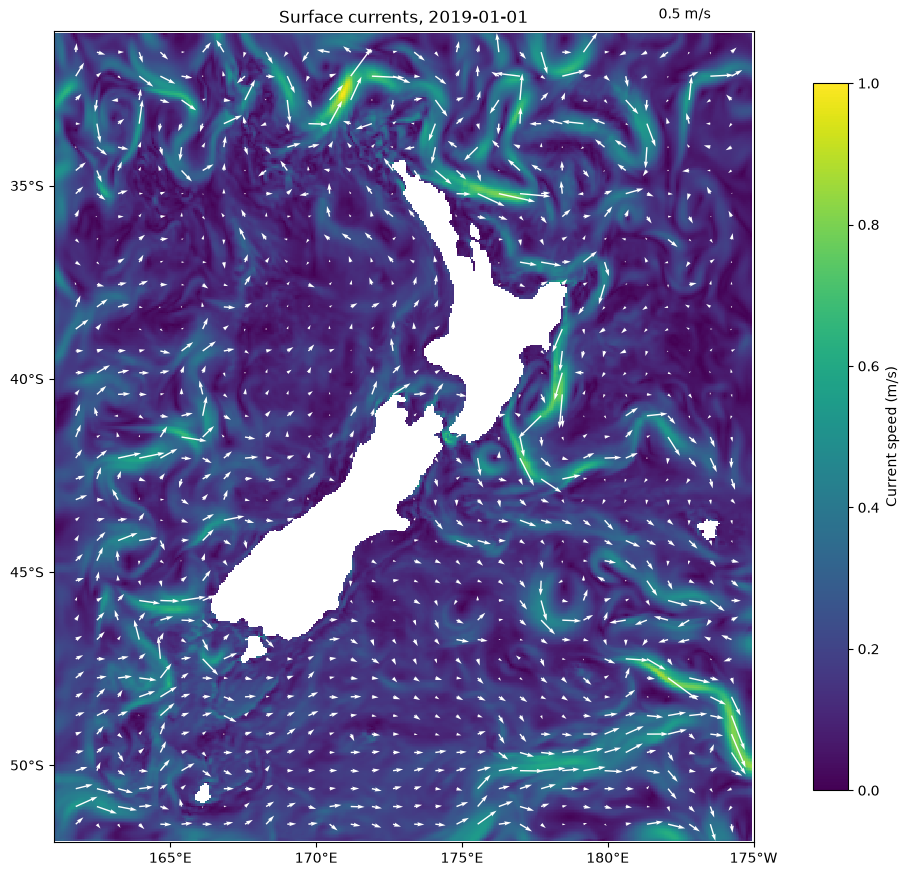

In [ ]:
# --- Plot Currents ---
t = 0
s = ds.isel(ocean_time=t, s_rho=-1)          # surface, one time
lon = s["lon_rho"].values
lat = s["lat_rho"].values

# 1) average u and v onto rho points (cell centres)
u = s["u"].values
v = s["v"].values
u_rho = np.full(lon.shape, np.nan)
v_rho = np.full(lon.shape, np.nan)
u_rho[:, 1:-1] = 0.5 * (u[:, :-1] + u[:, 1:])
v_rho[1:-1, :] = 0.5 * (v[:-1, :] + v[1:, :])

# 2) rotate from grid directions to east/north
angle = ds["angle"].values                   # if missing: grd["angle"].values from your grid file
u_east  = u_rho * np.cos(angle) - v_rho * np.sin(angle)
v_north = u_rho * np.sin(angle) + v_rho * np.cos(angle)
speed = np.sqrt(u_east**2 + v_north**2)

# 3) plot: speed as colour, every n-th point as an arrow
n = 12                                        # arrow spacing (bigger = fewer arrows)
fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)

pc = ax.pcolormesh(lon, lat, speed, cmap="viridis", vmin=0, vmax=1, shading="auto")
fig.colorbar(pc, ax=ax, label="Current speed (m/s)", shrink=0.8)

q = ax.quiver(lon[::n, ::n], lat[::n, ::n], u_east[::n, ::n], v_north[::n, ::n],
              color="white", scale=15, width=0.002)
ax.quiverkey(q, X=0.85, Y=1.02, U=0.5, label="0.5 m/s", labelpos="E")

# same clean map styling as before
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}°E" if x <= 180 else f"{360 - x:.0f}°W"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{abs(y):.0f}°S"))
ax.set_aspect(1 / np.cos(np.deg2rad(41)))
ax.set_title(f"Surface currents, {str(s.ocean_time.values)[:10]}")

plt.savefig("../Figures/Jan2019_currents.png", dpi=200, bbox_inches="tight")
plt.show()